# Ablation results: demographics-only and speech-only

Based on evaluate_regression_and_transform_data.ipynb



In [26]:
import json
import os.path
import os
from typing import Iterable

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pingouin as pg
from pathlib import Path

from pandas import MultiIndex, IndexSlice
from scipy.stats import pearsonr
from sklearn.metrics import r2_score, mean_squared_error

from datetime import datetime
now = lambda: datetime.now().strftime("%Y-%m-%d %H:%M")


from config.constants import Constants
C = Constants()

In [27]:
targets = ['language', 'memory', 'executive_function', 'speed']
#targets = ['language']
target_cols = ['composite_'+t for t in targets]
tasks = ['cookieTheft', 'picnicScene', 'journaling']

VERSION = 'kw19_withoutCohortB'  # combined model
VERSION = "demographics_only"
#VERSION = "speech_only"
#VERSION = 'linguistic_only'

if VERSION == 'kw19_withoutCohortB':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw20/20260513_0936_69ea_svr_rbf_wave1_cohortA')
    base_dir_test = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw20/20260513_0936_69ea_svr_rbf_test_on_cohortB')
    base_dirs = [base_dir_cv, base_dir_test]
    SUBDIR_FILTER = ""
elif VERSION == 'demographics_only':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_wave1_cohortA')
    base_dir_test = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_test_on_cohortB')
    base_dirs = [base_dir_cv, base_dir_test]
    SUBDIR_FILTER = "demographics_only"
elif VERSION == 'speech_only':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_wave1_cohortA')
    base_dir_test = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_test_on_cohortB')
    base_dirs = [base_dir_cv, base_dir_test]
    SUBDIR_FILTER = "speech_only"
elif VERSION == 'linguistic_only':
    base_dir_cv = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw34/20260821_0924_9087_svr_rbf_wave1_cohortA')
    base_dir_test = Path('/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw34/20260821_0924_9087_svr_rbf_test_on_cohortB')
    base_dirs = [base_dir_cv, base_dir_test]
    SUBDIR_FILTER = ""
else:
    raise ValueError(f'Unknown VERSION: {VERSION}')

waves_and_ids_path = Path(C.DATA_PROCESSED_COMBINED_2026) / Path('data/waves_and_ids.csv')
print(waves_and_ids_path)

# Cohort definitions: (label, wave_a, wave_b)
COHORTS = [
    ('A', 'wave1', 'wave2'),
    ('B', 'wave2', 'wave3'),
]
ALL_WAVES = ['wave1', 'wave2', 'wave3']

/Users/jheitz/git/luha-prolific-study/data2026/processed_combined/data/waves_and_ids.csv


In [28]:
waves_and_ids = pd.read_csv(waves_and_ids_path, dtype=str).rename(
    columns={'longitudinal_id': 'sample_name_longitudinal', 'study_submission_id': 'sample_name'}
)


def get_longitudinal_participants(waves_and_ids, wave_a, wave_b):
    """Return rows for participants present in BOTH wave_a and wave_b."""
    sub = waves_and_ids[waves_and_ids['wave'].isin([wave_a, wave_b])]
    return sub.groupby('sample_name_longitudinal').filter(
        lambda g: set(g['wave']) == {wave_a, wave_b}
    )


longitudinal_participants_by_cohort = {
    label: get_longitudinal_participants(waves_and_ids, wave_a, wave_b)
    for label, wave_a, wave_b in COHORTS
}

for label, wave_a, wave_b in COHORTS:
    n = longitudinal_participants_by_cohort[label]['sample_name_longitudinal'].nunique()
    print(f'Cohort {label} ({wave_a} - {wave_b}): {n} longitudinal participants')

Cohort A (wave1 - wave2): 305 longitudinal participants
Cohort B (wave2 - wave3): 70 longitudinal participants


In [29]:
def load_prediction_and_target(base_dirs, task, target_col):
    """Load prediction_and_target.csv for a given task and target from the results directory."""
    df_base_dirs = []
    for base_dir in base_dirs:
        print(f'Loading prediction_and_target.csv for task={task}, target={target_col}, base_dir={base_dir}')
        found = False
        for subdir in base_dir.iterdir():
            if not subdir.is_dir():
                continue
            if not SUBDIR_FILTER in subdir.name:
                continue
            config_path = subdir / 'config.json'
            if not config_path.exists():
                continue
            with open(config_path) as f:
                config = json.load(f)
            if config['config_model']['target_variable'] != target_col:
                continue
            df = pd.read_csv(
                subdir / 'prediction_and_target.csv', index_col=0, dtype={'sample_name': str}
            ).query(f"task == '{task}'").drop(columns=['task'])
            print(f'  Loaded from {base_dir.name}/{subdir.name} - shape: {df.shape}')
            df_with_wave = df.merge(waves_and_ids[['sample_name', 'wave']], on='sample_name', how='left')
            assert df.shape[0] == df_with_wave.shape[0]
            df_base_dirs.append(df_with_wave)
            found = True
        if not found:
            raise FileNotFoundError(f'No results found for task={task}, target={target_col}, base_dir={base_dir}')
    return pd.concat(df_base_dirs)

## Cross-sectional dataframe (all waves pooled)

In [30]:
target_dfs = []
for target_col, target in zip(target_cols, targets):
    dfs = []
    for task in tasks:
        df = load_prediction_and_target(base_dirs, task, target_col).set_index('sample_name')
        df = df.rename(columns={'prediction': task, target_col: f'target'})
        df = df.drop(columns=['split_idx'])
        df.columns = pd.MultiIndex.from_tuples([(target, c) for c in df.columns])
        dfs.append(df)

    target_df = pd.concat(dfs, axis=1, join='outer')
    #print(target_df.columns)
    duplicated_numerical_columns = target_df.select_dtypes(include='number').columns.duplicated(keep=False)
    assert target_df.select_dtypes(include='number').loc[:, duplicated_numerical_columns].std(axis=1).max() <= 1e-6, \
        f'Duplicated columns have different values for target {target}'
    target_df = target_df.loc[:, ~target_df.columns.duplicated()]
    target_df = target_df.sort_index(key=lambda idx: pd.Series(idx).apply(lambda s: int(s)))
    target_dfs.append(target_df)

    assert target_df.index.nunique() == target_df.index.shape[0], f"Should only have one row per sample name, but there are {target_df.index.nunique()} vs  {target_df.index.shape[0]}"



if not os.path.exists("transformed_data"):
    os.mkdir("transformed_data")
crosssectional = pd.concat(target_dfs, axis=1, join='outer')
crosssectional.to_csv(f"transformed_data/{VERSION}_predictions_targets_crosssectional.csv")
crosssectional

Loading prediction_and_target.csv for task=cookieTheft, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_wave1_cohortA
  Loaded from 20260804_1533_abc5_svr_rbf_wave1_cohortA/20260804_1533_svr_rbf_svr_all_individual_demographics_only_all_individual_composite_language_gamma0.001-epsilon0.321471781635738-C3.359818286283781_dccb - shape: (1282, 4)
Loading prediction_and_target.csv for task=cookieTheft, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Students/Jonathan/results/runs_luha/2026_kw32/20260804_1533_abc5_svr_rbf_test_on_cohortB
  Loaded from 20260804_1533_abc5_svr_rbf_test_on_cohortB/20260804_1641_svr_rbf_svr_all_individual_demographics_only_all_individual_composite_language_gamma0.001-epsilon0.321471781635738-C3.359818286283781_pcsw - shape: (172, 4)
Loading prediction_and_target.csv for task=picnicScene, target=composite_language, base_dir=/Volumes/g_psyplafor_methlab$/Stu

language                                              memory  \
               target cookieTheft   wave picnicScene journaling    target   
sample_name                                                                 
83           0.127514    0.198834  wave1    0.198719   0.198740 -0.020842   
84           1.591000    0.164175  wave1    0.164067   0.164177  0.823007   
85          -0.137563    0.684914  wave1    0.684042   0.684360 -0.141288   
86           0.084998    0.222571  wave1    0.222529   0.222208 -0.446685   
88           0.123648    0.091572  wave1    0.091668   0.091482  0.105457   
...               ...         ...    ...         ...        ...       ...   
1946         1.059569    0.547761  wave3    0.546774   0.546810  0.009962   
1947         1.380432    0.076394  wave3    0.075880   0.076156  0.433639   
1949        -0.021867    0.198553  wave3    0.198137   0.197856 -0.545741   
1950         0.536164    0.307820  wave3    0.307256   0.307053 -0.149979   
1951         1.568476    0.613366  wave3    0.612327   0.612304  1.666154   

                                                      executive_function  \
            cookieTheft   wave picnicScene journaling             target   
sample_name                                                                
83             0.198205  wave1    0.198113   0.197884           0.904932   
84             0.278346  wave1    0.277995   0.278090           0.985080   
85             0.654063  wave1    0.653208   0.653376          -1.452760   
86             0.178429  wave1    0.178089   0.178528           0.204441   
88            -0.213991  wave1   -0.213748  -0.213478           0.268657   
...                 ...    ...         ...        ...                ...   
1946           0.575877  wave3    0.575005   0.574876           0.523724   
1947           0.012765  wave3    0.012633   0.012520           1.147031   
1949          -0.077029  wave3   -0.077069  -0.077238           0.232663   
1950          -0.050152  wave3   -0.050201  -0.050314           0.768990   
1951           0.680722  wave3    0.679682   0.679552           1.409382   

                                                          speed              \
            cookieTheft   wave picnicScene journaling    target cookieTheft   
sample_name                                                                   
83             0.131974  wave1    0.132139   0.132143 -0.293125    0.141914   
84             0.015135  wave1    0.015212   0.015182  0.270390   -0.122592   
85             0.518146  wave1    0.517764   0.517698 -1.356772    0.400480   
86             0.318718  wave1    0.318380   0.318230 -1.062785    0.268115   
88             0.209217  wave1    0.209092   0.208902 -0.234306    0.277016   
...                 ...    ...         ...        ...       ...         ...   
1946           0.454810  wave3    0.454266   0.454273  0.286316    0.299688   
1947           0.189548  wave3    0.189468   0.189365  0.389651    0.089076   
1949           0.228480  wave3    0.228299   0.228317  0.192694    0.082078   
1950           0.505445  wave3    0.504853   0.504951  0.849361    0.267058   
1951           0.430025  wave3    0.429511   0.429473  1.455907    0.342581   

                                           
              wave picnicScene journaling  
sample_name                                
83           wave1    0.142000   0.142271  
84           wave1   -0.121880  -0.121632  
85           wave1    0.400179   0.400145  
86           wave1    0.268567   0.267942  
88           wave1    0.277457   0.276979  
...            ...         ...        ...  
1946         wave3    0.299403   0.299699  
1947         wave3    0.089071   0.089270  
1949         wave3    0.082163   0.082429  
1950         wave3    0.266832   0.267115  
1951         wave3    0.342262   0.342553  

[1454 rows x 20 columns]

## Longitudinal dataframes per cohort

In [31]:
def build_longitudinal(crosssectional, longitudinal_participants, wave_a, wave_b):
    """Build a wide longitudinal df indexed by sample_name_longitudinal,
    with columns (wave, target, col) for the two cohort waves."""
    waves = [wave_a, wave_b]
    longitudinal_dfs = []
    for wave in waves:
        lp_wave = longitudinal_participants[longitudinal_participants['wave'] == wave][
            ['sample_name_longitudinal', 'sample_name']
        ]
        lp_wave.columns = pd.MultiIndex.from_tuples([(c, '') for c in lp_wave.columns])
        df = crosssectional.merge(
            lp_wave, left_index=True, right_on='sample_name', how='inner'
        ).set_index('sample_name_longitudinal')
        # Sanity check: every row should be from the requested wave
        any_target = targets[0]
        assert np.all(df[(any_target, 'wave')] == wave), (
            f'Mismatched wave column when building longitudinal for {wave}'
        )
        df = df.drop(columns=['sample_name'], level=0)
        df.columns = pd.MultiIndex.from_tuples([(wave, target, col) for target, col in df.columns])
        longitudinal_dfs.append(df)

    return pd.concat(longitudinal_dfs, axis=1, join='outer').sort_index()


longitudinal_by_cohort = {}
for label, wave_a, wave_b in COHORTS:
    long_df = build_longitudinal(
        crosssectional,
        longitudinal_participants_by_cohort[label],
        wave_a, wave_b,
    )
    long_df.to_csv(
        f"transformed_data/{VERSION}_predictions_targets_longitudinal_cohort{label}.csv"
    )
    longitudinal_by_cohort[label] = long_df
    print(f'Cohort {label} ({wave_a} ↔ {wave_b}): longitudinal shape = {long_df.shape}')

longitudinal_by_cohort['A'].head()

Cohort A (wave1 ↔ wave2): longitudinal shape = (305, 40)
Cohort B (wave2 ↔ wave3): longitudinal shape = (70, 40)


wave1                                            \
                          language                                             
                            target cookieTheft   wave picnicScene journaling   
sample_name_longitudinal                                                       
01d1fdfc3a               -0.092677   -0.194295  wave1   -0.193692  -0.193896   
0367083668                1.124401    0.079198  wave1    0.079242   0.079293   
048eb2a01e                0.894593    0.374178  wave1    0.373368   0.373700   
049af4901b                0.983548   -0.240723  wave1   -0.240651  -0.240335   
04d9f72ef8                0.588701   -0.036491  wave1   -0.036299  -0.036202   

                                                                              \
                            memory                                             
                            target cookieTheft   wave picnicScene journaling   
sample_name_longitudinal                                                       
01d1fdfc3a                0.327517    0.197190  wave1    0.196877   0.196598   
0367083668                0.184961    0.460718  wave1    0.460579   0.460474   
048eb2a01e                0.046646    0.383872  wave1    0.383433   0.383835   
049af4901b                0.143516    0.124998  wave1    0.124934   0.125359   
04d9f72ef8               -0.415460    0.375510  wave1    0.375487   0.375415   

                          ...              wave2                     \
                          ... executive_function                      
                          ...             target cookieTheft   wave   
sample_name_longitudinal  ...                                         
01d1fdfc3a                ...          -2.357971    0.011299  wave2   
0367083668                ...           0.944384    0.175642  wave2   
048eb2a01e                ...           0.211813    0.308089  wave2   
049af4901b                ...           0.491533   -0.054545  wave2   
04d9f72ef8                ...          -0.744793   -0.013738  wave2   

                                                                              \
                                                    speed                      
                         picnicScene journaling    target cookieTheft   wave   
sample_name_longitudinal                                                       
01d1fdfc3a                  0.011550   0.011295 -2.152385    0.095283  wave2   
0367083668                  0.175880   0.175934  1.470132    0.185144  wave2   
048eb2a01e                  0.307880   0.307781  0.262024    0.328252  wave2   
049af4901b                 -0.054209  -0.054302  0.732080    0.156748  wave2   
04d9f72ef8                 -0.013250  -0.013229  0.112349    0.047050  wave2   

                                                 
                                                 
                         picnicScene journaling  
sample_name_longitudinal                         
01d1fdfc3a                  0.095551   0.095302  
0367083668                  0.184978   0.185079  
048eb2a01e                  0.327688   0.328044  
049af4901b                  0.156465   0.156750  
04d9f72ef8                  0.046988   0.047083  

[5 rows x 40 columns]

## Scatter plots: predictions across waves

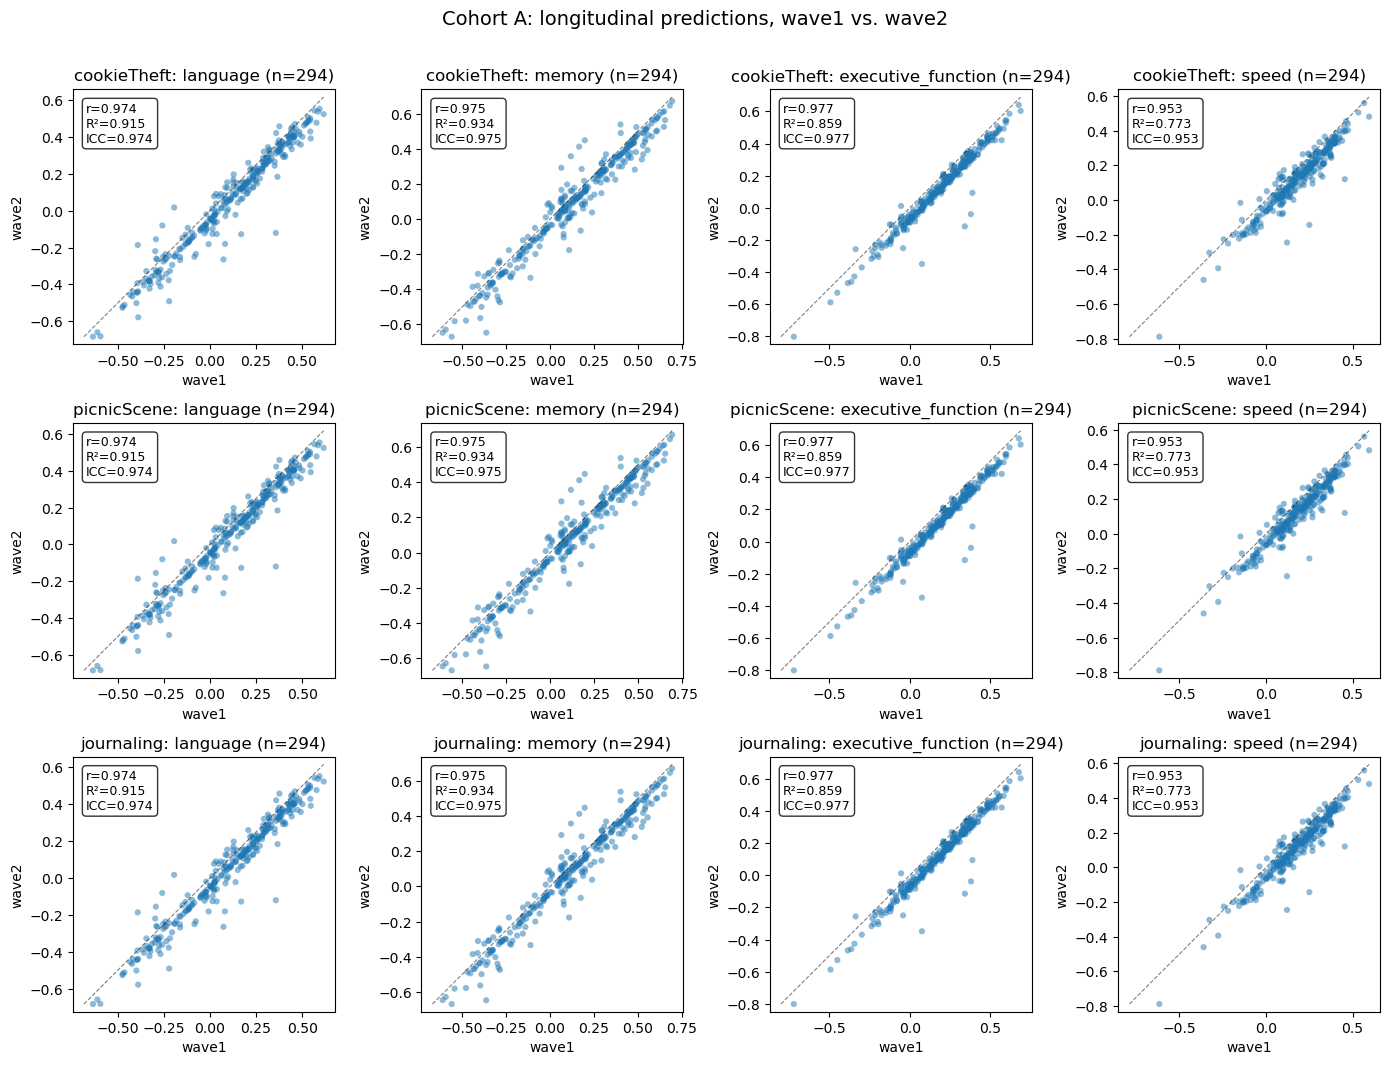

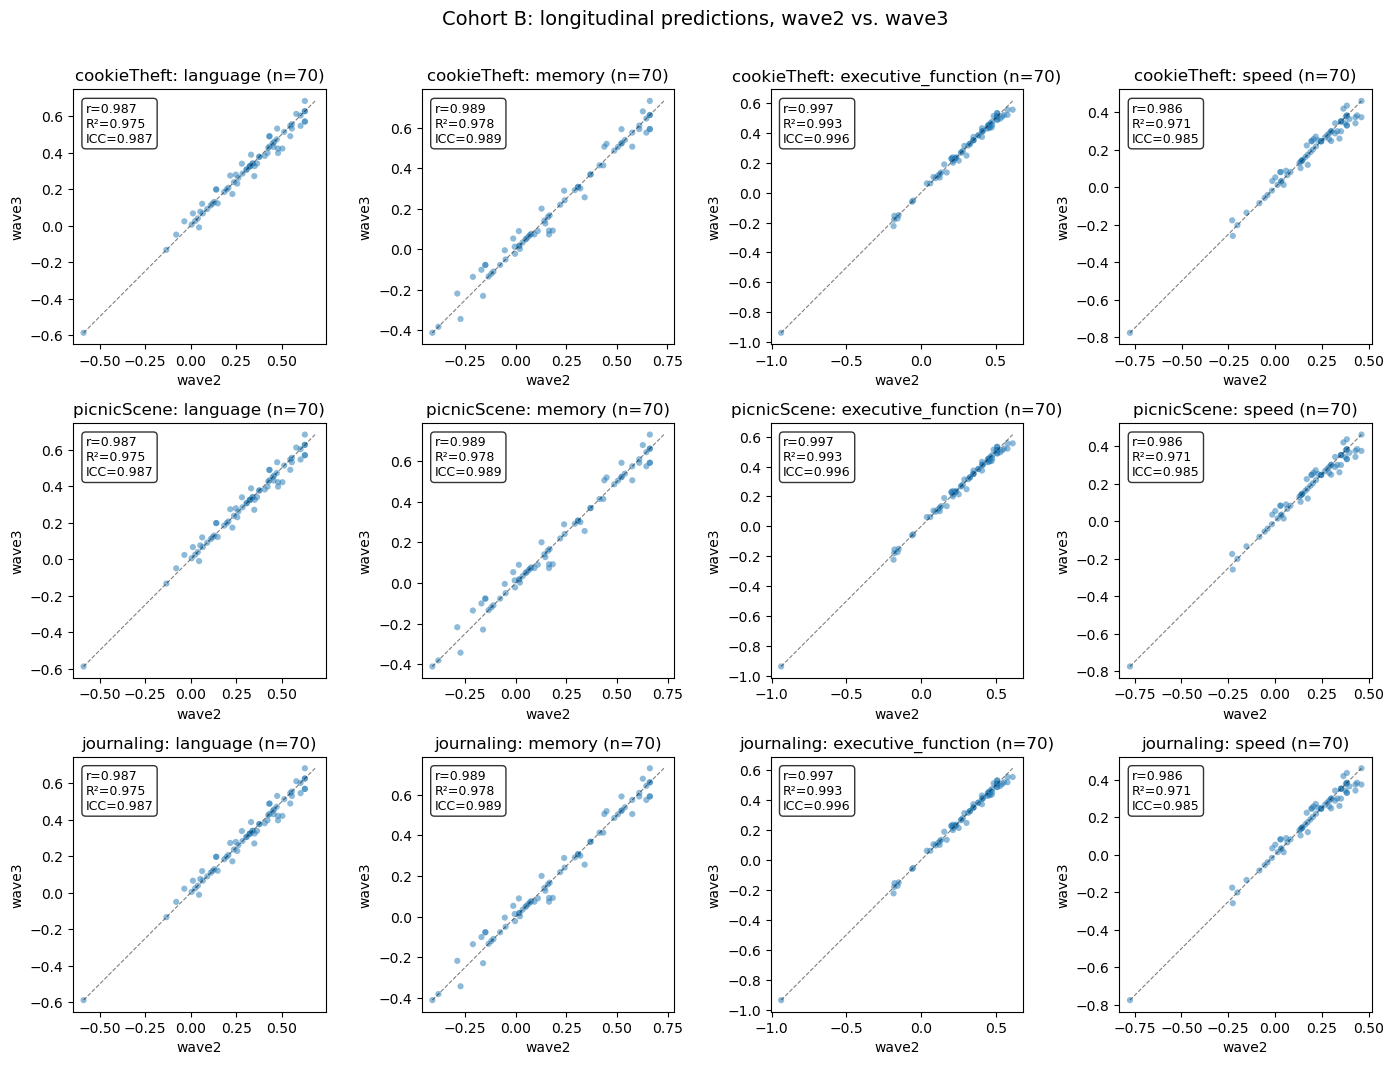

In [32]:
def compute_icc(df, val_1_col, val_2_col, id_col):
    """Compute ICC3 between two repeated measures."""
    df_melted = df.reset_index().melt(
        id_vars=[id_col],
        value_vars=[val_1_col, val_2_col],
        var_name='wave',
        value_name='score',
    )
    df_melted.columns = ['id', 'wave', 'score']
    icc = pg.intraclass_corr(
        data=df_melted, targets='id', raters='wave',
        ratings='score', nan_policy='omit',
    )
    return icc[icc['Type'] == 'ICC3'].iloc[0]['ICC']


def plot_paired_scatter(longitudinal, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        len(tasks), len(targets),
        figsize=(3.5 * len(targets), 3.5 * len(tasks)),
    )
    for row_idx, task in enumerate(tasks):
        for col_idx, target in enumerate(targets):
            if len(targets) > 1:
                ax = axes[row_idx, col_idx]
            else:
                ax = axes[row_idx] if len(tasks) > 1 else axes

            val_1_col = (wave_a, target, task)
            val_2_col = (wave_b, target, task)
            df_here = longitudinal.loc[:, [val_1_col, val_2_col]].copy().dropna()
            x, y = df_here.loc[:, val_1_col], df_here.loc[:, val_2_col]
            r_val, _ = pearsonr(x, y)
            r2_val = r2_score(x, y)
            icc_val = compute_icc(
                df_here,
                val_1_col=val_1_col, val_2_col=val_2_col,
                id_col=('sample_name_longitudinal', '', ''),
            )

            ax.scatter(x, y, alpha=0.5, s=20, edgecolors='none')
            lims = [min(x.min(), y.min()), max(x.max(), y.max())]
            ax.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5)
            ax.set_xlabel(wave_a)
            ax.set_ylabel(wave_b)
            ax.set_title(f'{task}: {target} (n={len(df_here)})')
            ax.text(
                0.05, 0.95,
                f'r={r_val:.3f}\nR\u00b2={r2_val:.3f}\nICC={icc_val:.3f}',
                transform=ax.transAxes, fontsize=9,
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
            )
            ax.set_aspect('equal', adjustable='datalim')

    fig.suptitle(
        f'Cohort {label}: longitudinal predictions, {wave_a} vs. {wave_b}',
        fontsize=14, y=1.01,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_paired_scatter(longitudinal_by_cohort[label], label, wave_a, wave_b, targets, tasks)

## Prediction performance: R² and MSE

Pooled metrics use the cross-sectional dataframe and appear once. Per-cohort longitudinal subsets are stacked into the same `eval_df` with a `cohort` column.

In [33]:


def rename_target(target):
    if target == 'language':
        return 'Language'
    elif target == 'executive_function':
        return 'Executive Function'
    elif target == 'memory':
        return 'Memory'
    elif target == 'speed':
        return 'Speed'
    return target.replace('_', ' ').title()


rename_tasks = {
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling',
        'average_prediction': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
    }
def rename_task(task):
    return rename_tasks.get(task, task.replace('_', ' ').title())

def bootstrap_metric(y_true, y_pred, metric_func, n_boot=1000, seed=0):
    """Return (point_estimate, ci_low, ci_high) via paired bootstrap over samples."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    point = metric_func(y_true, y_pred)
    rng_local = np.random.default_rng(seed)
    n = len(y_true)
    boot_vals = np.empty(n_boot)
    for i in range(n_boot):
        idx = rng_local.integers(0, n, size=n)
        boot_vals[i] = metric_func(y_true[idx], y_pred[idx])
    ci_low, ci_high = np.percentile(boot_vals, [2.5, 97.5])
    return point, ci_low, ci_high


def _metrics_row(y_true, y_pred, cohort, subset, target, task, n_boot, seed):
    r2, r2_lo, r2_hi = bootstrap_metric(y_true, y_pred, r2_score, n_boot=n_boot, seed=seed)
    mse, mse_lo, mse_hi = bootstrap_metric(y_true, y_pred, mean_squared_error, n_boot=n_boot, seed=seed)
    n = len(y_true)
    denominator_r2 = np.sum(np.square(y_true - np.mean(y_true)))
    numerator_r2 = np.sum(np.square(y_true - y_pred))
    y_var = np.var(y_true)
    assert np.abs(n*y_var - denominator_r2) < 0.001, \
        f"n*y_var={n*y_var:.3f} vs denominator_r2={denominator_r2:.3f}"
    r2_alt = 1 - numerator_r2/denominator_r2
    assert np.abs(r2_alt - r2) < 0.001, f"r2_alt={r2_alt:.3f} vs r2={r2:.3f}"
    assert np.abs(1 - (mse / y_var) - r2) < 0.001, \
        f"mse/y_var={mse/y_var:.3f} vs r2={r2:.3f}"
    return {
        'cohort': cohort, 'subset': subset, 'target': target, 'task': task,
        'n': n, 'y_var': y_var,
        'r2': r2, 'r2_ci_low': r2_lo, 'r2_ci_high': r2_hi,
        'mse': mse, 'mse_ci_low': mse_lo, 'mse_ci_high': mse_hi,
    }


def _add_pooled_rows(rows, crosssectional, targets, tasks, n_boot, seed):
    for target in targets:
        y_true = crosssectional[(target, 'target')]
        for task in tasks:
            rows.append(_metrics_row(
                y_true, crosssectional[(target, task)],
                cohort='-', subset='pooled', target=target, task=task,
                n_boot=n_boot, seed=seed,
            ))
        pred_avg = crosssectional.loc[:, [(target, t) for t in tasks]].mean(axis=1)
        rows.append(_metrics_row(
            y_true, pred_avg,
            cohort='-', subset='pooled', target=target, task='average',
            n_boot=n_boot, seed=seed,
        ))


def _add_cohort_rows_old(rows, longitudinal, cohort, wave_a, wave_b, targets, tasks, n_boot, seed):
    for wave in [wave_a, wave_b]:
        for target in targets:
            y_true = longitudinal[(wave, target, 'target')]
            for task in tasks:
                rows.append(_metrics_row(
                    y_true, longitudinal[(wave, target, task)],
                    cohort=cohort, subset=f'{wave}_longitudinal',
                    target=target, task=task,
                    n_boot=n_boot, seed=seed,
                ))
            pred_avg = longitudinal.loc[:, [(wave, target, t) for t in tasks]].mean(axis=1)
            rows.append(_metrics_row(
                y_true, pred_avg,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='average',
                n_boot=n_boot, seed=seed,
            ))
            pred_pictureDescription = longitudinal.loc[
                :, [(wave, target, t) for t in ['picnicScene', 'cookieTheft']]
            ].mean(axis=1)
            rows.append(_metrics_row(
                y_true, pred_pictureDescription,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='pictureDescription',
                n_boot=n_boot, seed=seed,
            ))


def _add_cohort_rows(rows, longitudinal, cohort, wave_a, wave_b, targets, tasks, n_boot, seed):
    for target in targets:
        # individual tasks
        for task in tasks:
            wave_rows = []
            for wave in [wave_a, wave_b]:
                y_true = longitudinal[(wave, target, 'target')]
                row = _metrics_row(
                    y_true, longitudinal[(wave, target, task)],
                    cohort=cohort, subset=f'{wave}_longitudinal',
                    target=target, task=task,
                    n_boot=n_boot, seed=seed,
                )
                wave_rows.append(row)
                rows.append(row)
            rows.append({
                'cohort': cohort, 'subset': 'mean_wave', 'target': target, 'task': task,
                **pd.DataFrame(wave_rows)[['n','y_var','r2','r2_ci_low', 'r2_ci_high', 'mse', 'mse_ci_low', 'mse_ci_high']].mean(axis=0).to_dict(),
            })


        # avg prediction
        wave_rows = []
        for wave in [wave_a, wave_b]:
            y_true = longitudinal[(wave, target, 'target')]
            pred_avg = longitudinal.loc[:, [(wave, target, t) for t in tasks]].mean(axis=1)
            row = _metrics_row(
                y_true, pred_avg,
                cohort=cohort, subset=f'{wave}_longitudinal',
                target=target, task='average',
                n_boot=n_boot, seed=seed,
            )
            wave_rows.append(row)
            rows.append(row)
        rows.append({
            'cohort': cohort, 'subset': 'mean_wave', 'target': target, 'task': 'average',
            **pd.DataFrame(wave_rows)[['n','y_var','r2','r2_ci_low', 'r2_ci_high', 'mse', 'mse_ci_low', 'mse_ci_high']].mean(axis=0).to_dict(),
        })




def build_eval_df(crosssectional, longitudinal_by_cohort, cohorts, targets, tasks,
                  n_boot=1000, seed=0):
    """Long-format dataframe of R2 and MSE.

    Pooled rows appear once (cohort='-'). Per-cohort longitudinal rows are
    stacked with a `cohort` column.
    """
    rows = []
    _add_pooled_rows(rows, crosssectional, targets, tasks, n_boot, seed)
    for label, wave_a, wave_b in cohorts:
        _add_cohort_rows(
            rows, longitudinal_by_cohort[label].dropna(), label,
            wave_a, wave_b, targets, tasks, n_boot, seed,
        )
    return pd.DataFrame(rows)

In [34]:
eval_df = build_eval_df(
    crosssectional, longitudinal_by_cohort, COHORTS, targets, tasks,
    n_boot=10000, seed=0,
)
eval_df

,cohort,subset,target,task,n,y_var,r2,r2_ci_low,r2_ci_high,mse,mse_ci_low,mse_ci_high
0,-,pooled,language,cookieTheft,1454.0,0.993606,0.093058,0.066923,0.117794,0.901143,0.830973,0.974663
1,-,pooled,language,picnicScene,1454.0,0.993606,0.093035,0.066949,0.117733,0.901165,0.831005,0.974686
2,-,pooled,language,journaling,1454.0,0.993606,0.093027,0.066939,0.117715,0.901174,0.831011,0.974710
3,-,pooled,language,average,1454.0,0.993606,0.093040,0.066948,0.117748,0.901161,0.830998,0.974686
4,-,pooled,memory,cookieTheft,1454.0,1.033315,0.076216,0.045060,0.104476,0.954560,0.884616,1.027936
...,...,...,...,...,...,...,...,...,...,...,...,...
107,B,wave3_longitudinal,speed,journaling,70.0,0.884469,0.021895,-0.095508,0.102140,0.865103,0.499366,1.343504
108,B,mean_wave,speed,journaling,70.0,0.931084,0.012451,-0.114559,0.100137,0.919931,0.536042,1.411582
109,B,wave2_longitudinal,speed,average,70.0,0.977700,0.003023,-0.133548,0.098173,0.974744,0.572735,1.479662
110,B,wave3_longitudinal,speed,average,70.0,0.884469,0.021862,-0.095591,0.102151,0.865133,0.499373,1.343502


In [35]:
# Wide views: tasks (incl. 'average') as columns.
# Each cell is "<metric> [ci_low, ci_high]"
def make_wide(eval_df, metric):
    df = eval_df.copy()
    df[f'{metric}_str'] = df.apply(
        lambda r: f"{r[metric]:.2f} [{r[f'{metric}_ci_low']:.2f}, {r[f'{metric}_ci_high']:.2f}]",
        axis=1,
    )
    index_cols = ['cohort', 'subset', 'target', 'n']
    if metric == 'r2' or True:
        index_cols.append('y_var')
    wide = df.pivot_table(
        index=index_cols, columns='task', values=f'{metric}_str', aggfunc='first',
    ).loc[:, tasks + ['average']]
    wide.columns.name = None
    return wide


eval_wide_r2 = make_wide(eval_df, 'r2')
eval_wide_mse = make_wide(eval_df, 'mse')
eval_wide_r2

cookieTheft  \
cohort subset             target             n      y_var                           
-      pooled             executive_function 1454.0 0.975906    0.05 [0.03, 0.08]   
                          language           1454.0 0.993606    0.09 [0.07, 0.12]   
                          memory             1454.0 1.033315    0.08 [0.05, 0.10]   
                          speed              1454.0 0.972025   0.01 [-0.01, 0.03]   
A      mean_wave          executive_function 294.0  0.955518   0.05 [-0.01, 0.10]   
                          language           294.0  0.904488   0.05 [-0.03, 0.11]   
                          memory             294.0  1.117062    0.09 [0.02, 0.15]   
                          speed              294.0  0.892472   0.01 [-0.03, 0.06]   
       wave1_longitudinal executive_function 294.0  0.929150   0.03 [-0.02, 0.08]   
                          language           294.0  0.917438   0.06 [-0.01, 0.12]   
                          memory             294.0  0.998989   0.07 [-0.01, 0.13]   
                          speed              294.0  0.884753  -0.00 [-0.05, 0.04]   
       wave2_longitudinal executive_function 294.0  0.981885    0.06 [0.00, 0.12]   
                          language           294.0  0.891537   0.03 [-0.05, 0.10]   
                          memory             294.0  1.235134    0.11 [0.05, 0.17]   
                          speed              294.0  0.900190   0.03 [-0.02, 0.07]   
B      mean_wave          executive_function 70.0   0.667868   0.09 [-0.10, 0.23]   
                          language           70.0   0.883644   0.13 [-0.04, 0.23]   
                          memory             70.0   0.794757   0.16 [-0.03, 0.28]   
                          speed              70.0   0.931084   0.01 [-0.11, 0.10]   
       wave2_longitudinal executive_function 70.0   0.647493   0.04 [-0.10, 0.14]   
                          language           70.0   0.849189    0.17 [0.03, 0.24]   
                          memory             70.0   0.786900   0.17 [-0.02, 0.29]   
                          speed              70.0   0.977700   0.00 [-0.13, 0.10]   
       wave3_longitudinal executive_function 70.0   0.688244   0.14 [-0.10, 0.32]   
                          language           70.0   0.918099   0.10 [-0.11, 0.22]   
                          memory             70.0   0.802613   0.14 [-0.03, 0.27]   
                          speed              70.0   0.884469   0.02 [-0.10, 0.10]   

                                                                      picnicScene  \
cohort subset             target             n      y_var                           
-      pooled             executive_function 1454.0 0.975906    0.05 [0.03, 0.08]   
                          language           1454.0 0.993606    0.09 [0.07, 0.12]   
                          memory             1454.0 1.033315    0.08 [0.05, 0.10]   
                          speed              1454.0 0.972025   0.01 [-0.01, 0.03]   
A      mean_wave          executive_function 294.0  0.955518   0.05 [-0.01, 0.10]   
                          language           294.0  0.904488   0.05 [-0.03, 0.11]   
                          memory             294.0  1.117062    0.09 [0.02, 0.15]   
                          speed              294.0  0.892472   0.01 [-0.03, 0.06]   
       wave1_longitudinal executive_function 294.0  0.929150   0.03 [-0.02, 0.08]   
                          language           294.0  0.917438   0.06 [-0.01, 0.12]   
                          memory             294.0  0.998989   0.07 [-0.01, 0.13]   
                          speed              294.0  0.884753  -0.00 [-0.05, 0.04]   
       wave2_longitudinal executive_function 294.0  0.981885    0.06 [0.00, 0.11]   
                          language           294.0  0.891537   0.03 [-0.05, 0.10]   
                          memory             294.0  1.235134    0.11 [0.05, 0.17]   
                          speed              294.0  0.900190   0.03 [-0.02

In [36]:
rename_cols = {
        'subset': 'Assessment',
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling', 'target': 'Composite Score',
        'average': 'Avg. Prediction', 'pictureDescription': 'Avg. Picture Desc.',
        'y_var': '$\\Var(y)$',
    }


In [37]:
eval_wide_mse

cookieTheft  \
cohort subset             target             n      y_var                         
-      pooled             executive_function 1454.0 0.975906  0.92 [0.85, 1.01]   
                          language           1454.0 0.993606  0.90 [0.83, 0.97]   
                          memory             1454.0 1.033315  0.95 [0.88, 1.03]   
                          speed              1454.0 0.972025  0.96 [0.88, 1.05]   
A      mean_wave          executive_function 294.0  0.955518  0.91 [0.74, 1.09]   
                          language           294.0  0.904488  0.86 [0.73, 1.01]   
                          memory             294.0  1.117062  1.02 [0.84, 1.20]   
                          speed              294.0  0.892472  0.88 [0.71, 1.07]   
       wave1_longitudinal executive_function 294.0  0.929150  0.90 [0.72, 1.09]   
                          language           294.0  0.917438  0.86 [0.72, 1.02]   
                          memory             294.0  0.998989  0.93 [0.78, 1.11]   
                          speed              294.0  0.884753  0.89 [0.71, 1.09]   
       wave2_longitudinal executive_function 294.0  0.981885  0.92 [0.76, 1.10]   
                          language           294.0  0.891537  0.86 [0.73, 1.01]   
                          memory             294.0  1.235134  1.10 [0.91, 1.30]   
                          speed              294.0  0.900190  0.87 [0.72, 1.05]   
B      mean_wave          executive_function 70.0   0.667868  0.60 [0.42, 0.81]   
                          language           70.0   0.883644  0.77 [0.50, 1.09]   
                          memory             70.0   0.794757  0.67 [0.50, 0.85]   
                          speed              70.0   0.931084  0.92 [0.54, 1.41]   
       wave2_longitudinal executive_function 70.0   0.647493  0.62 [0.42, 0.85]   
                          language           70.0   0.849189  0.71 [0.43, 1.05]   
                          memory             70.0   0.786900  0.65 [0.50, 0.80]   
                          speed              70.0   0.977700  0.97 [0.57, 1.48]   
       wave3_longitudinal executive_function 70.0   0.688244  0.59 [0.43, 0.78]   
                          language           70.0   0.918099  0.83 [0.57, 1.13]   
                          memory             70.0   0.802613  0.69 [0.49, 0.91]   
                          speed              70.0   0.884469  0.87 [0.50, 1.34]   

                                                                    picnicScene  \
cohort subset             target             n      y_var                         
-      pooled             executive_function 1454.0 0.975906  0.92 [0.85, 1.01]   
                          language           1454.0 0.993606  0.90 [0.83, 0.97]   
                          memory             1454.0 1.033315  0.95 [0.88, 1.03]   
                          speed              1454.0 0.972025  0.96 [0.88, 1.05]   
A      mean_wave          executive_function 294.0  0.955518  0.91 [0.74, 1.09]   
                          language           294.0  0.904488  0.86 [0.73, 1.01]   
                          memory             294.0  1.117062  1.02 [0.84, 1.20]   
                          speed              294.0  0.892472  0.88 [0.71, 1.07]   
       wave1_longitudinal executive_function 294.0  0.929150  0.90 [0.72, 1.09]   
                          language           294.0  0.917438  0.86 [0.72, 1.02]   
                          memory             294.0  0.998989  0.93 [0.78, 1.11]   
                          speed              294.0  0.884753  0.89 [0.71, 1.09]   
       wave2_longitudinal executive_function 294.0  0.981885  0.92 [0.76, 1.10]   
                          language           294.0  0.891537  0.86 [0.73, 1.01]   
                          memory             294.0  1.235134  1.10 [0.91, 1.30]   
                          speed              294.0  0.900190  0.87 [0.72, 1.05]   
B      mean_wave          executive_function 70.0   0.667868  0.60 [0.42, 0.81]   


In [38]:
def render_subset_label(subset, wave_a, wave_b):
    if subset == 'pooled':
        return 'All data'
    if subset == f'{wave_a}_longitudinal':
        return f'{wave_a.replace("wave", "Wave ")}'
    if subset == f'{wave_b}_longitudinal':
        return f'{wave_b.replace("wave", "Wave ")}'
    return subset




### LaTeX tables (one per cohort, all metrics and  targets)

In [39]:
def emit_full_table_mean_wave(eval_wide_r2, eval_wide_mse, label, targets,
                    target_filter=None, keep_var_y=True):
    """One table per cohort, both metrics, mean_wave subset only.

    Rows ordered: (metric, target). Each metric gets a \\multicolumn block
    header. Within each block, one row per target showing the mean_wave value.

    If target_filter is set, only that target is shown and no target header
    rows are emitted (but metric block headers are still shown).
    """
    if target_filter is not None:
        targets_to_use = [target_filter]
    else:
        targets_to_use = list(targets)

    metric_order = {'$R^2$': 0, 'MSE': 1}

    def prep(wide, metric_name):
        df = wide.reset_index()
        df = df[(df['target'].isin(targets_to_use)) & (df['cohort'] == label)].copy()
        df = df[df['subset'] == 'mean_wave']
        df['Metric'] = metric_name
        return df.drop(columns=['cohort', 'subset'])

    table = pd.concat(
        [prep(eval_wide_r2, '$R^2$'), prep(eval_wide_mse, 'MSE')],
        ignore_index=True,
    )

    table['_t'] = table['target'].apply(lambda t: targets_to_use.index(t))
    table['_m'] = table['Metric'].map(metric_order)
    table = table.sort_values(['_m', '_t']).drop(columns=['_t', '_m'])
    table = table.reset_index(drop=True)

    n_values = table['n'].dropna().unique()
    assert len(n_values) == 1, f'Expected one n per cohort, got {n_values}'
    n_value = int(n_values[0])

    rename_cols = {
        'target': 'Target',
        'cookieTheft': 'Cookie Theft', 'picnicScene': 'Picnic Scene',
        'journaling': 'Journaling',
        'average': 'Avg. Prediction',
        'y_var': '$\\Var(y)$',
    }
    table = table.rename(columns=rename_cols)
    table = table.drop(columns=['n'])

    table['Target'] = table['Target'].apply(rename_target)


    target_per_row = table['Target'].tolist()
    metric_per_row = table['Metric'].tolist()
    visible = table#.drop(columns=['Metric'])

    visible['Metric'] = np.where(visible['Metric'].shift() != visible['Metric'], visible['Metric'], '')
    visible['Metric'] = visible['Metric'].apply(
        #lambda v: f'\\multirow{{2}}{{*}}{{{v}}}' if v != '' else v
        lambda v: f"\\parbox[t]{{2mm}}{{\\multirow{{3}}{{*}}{{\\rotatebox[origin=c]{{90}}{{{v}}}}}}}" if v != '' else v
    )

    test_cols = [
        c for c in ['Cookie Theft', 'Picnic Scene', 'Journaling', 'Avg. Prediction']
        if c in visible.columns
    ]

    if keep_var_y:
        col_order = ['Metric', 'Target'] + test_cols + ['$\\Var(y)$']
    else:
        col_order = ['Metric', 'Target'] + test_cols
    visible = visible[[c for c in col_order if c in visible.columns]]

    visible = visible.rename(columns={'Metric': ''})

    r2_var_y_note = "Note that the variance in true scores ($\\Var(y)$) contributes to the $R^2$ calculation, with lower $\\Var(y)$ producing lower $R^2$ values given identical errors. " if keep_var_y else ""
    if target_filter is not None:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance for the \\textit{{{rename_target(target_filter)}}} composite score: $R^2$ and MSE of the prediction model on the mean over assessment waves. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}_{target_filter}'
    else:
        caption = (
            f"Cohort {label} ($n={n_value}$) regression performance: $R^2$ and MSE of the prediction model (mean over both assessments) for all composite score targets. We report point estimates with 95\\% bootstrap CI. {r2_var_y_note}"
        )
        tex_label = f'tab:regression_cohort{label}_mean_wave'

    n_cols = len(visible.columns)
    # Target (l), tasks + Var(y) (c)
    latex = visible.to_latex(
        float_format='%.2f',
        column_format='ll' + 'c' * (n_cols - 2),
        index=False,
        caption=caption,
        label=tex_label,
        escape=False,
        na_rep='',
    )

    lines = latex.splitlines()
    try:
        body_start = next(i for i, ln in enumerate(lines)
                          if ln.strip() == '\\midrule') + 1
        body_end = next(i for i, ln in enumerate(lines)
                        if ln.strip() == '\\bottomrule')
    except StopIteration:
        print(latex)
        return

    data_lines = lines[body_start:body_end]
    assert len(data_lines) == len(target_per_row)

    new_body = []
    prev_metric = None
    for i, (metric, tgt, row) in enumerate(zip(metric_per_row, target_per_row, data_lines)):
        if metric != prev_metric:
            if prev_metric is not None:
                new_body.append('\\midrule')
            #new_body.append(
            #    f'\\multicolumn{{{n_cols}}}{{c}}{{\\textit{{{metric}}}}} \\\\'
            #)
            prev_metric = metric
        new_body.append(row)

    print('\n'.join(lines[:body_start] + new_body + lines[body_end:]))

for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Regression results Cohort {label}, average cross waves, all target scores ({now()}) ===')
    emit_full_table_mean_wave(eval_wide_r2, eval_wide_mse, label, targets)




% === Regression results Cohort A, average cross waves, all target scores (2026-09-22 11:51) ===
\begin{table}
\caption{Cohort A ($n=294$) regression performance: $R^2$ and MSE of the prediction model (mean over both assessments) for all composite score targets. We report point estimates with 95\% bootstrap CI. Note that the variance in true scores ($\Var(y)$) contributes to the $R^2$ calculation, with lower $\Var(y)$ producing lower $R^2$ values given identical errors. }
\label{tab:regression_cohortA_mean_wave}
\begin{tabular}{llccccc}
\toprule
 & Target & Cookie Theft & Picnic Scene & Journaling & Avg. Prediction & $\Var(y)$ \\
\midrule
\parbox[t]{2mm}{\multirow{3}{*}{\rotatebox[origin=c]{90}{$R^2$}}} & Language & 0.05 [-0.03, 0.11] & 0.05 [-0.03, 0.11] & 0.05 [-0.03, 0.11] & 0.05 [-0.03, 0.11] & 0.90 \\
 & Memory & 0.09 [0.02, 0.15] & 0.09 [0.02, 0.15] & 0.09 [0.02, 0.15] & 0.09 [0.02, 0.15] & 1.12 \\
 & Executive Function & 0.05 [-0.01, 0.10] & 0.05 [-0.01, 0.10] & 0.05 [-0.01, 0.

### Bar plots: one figure per cohort

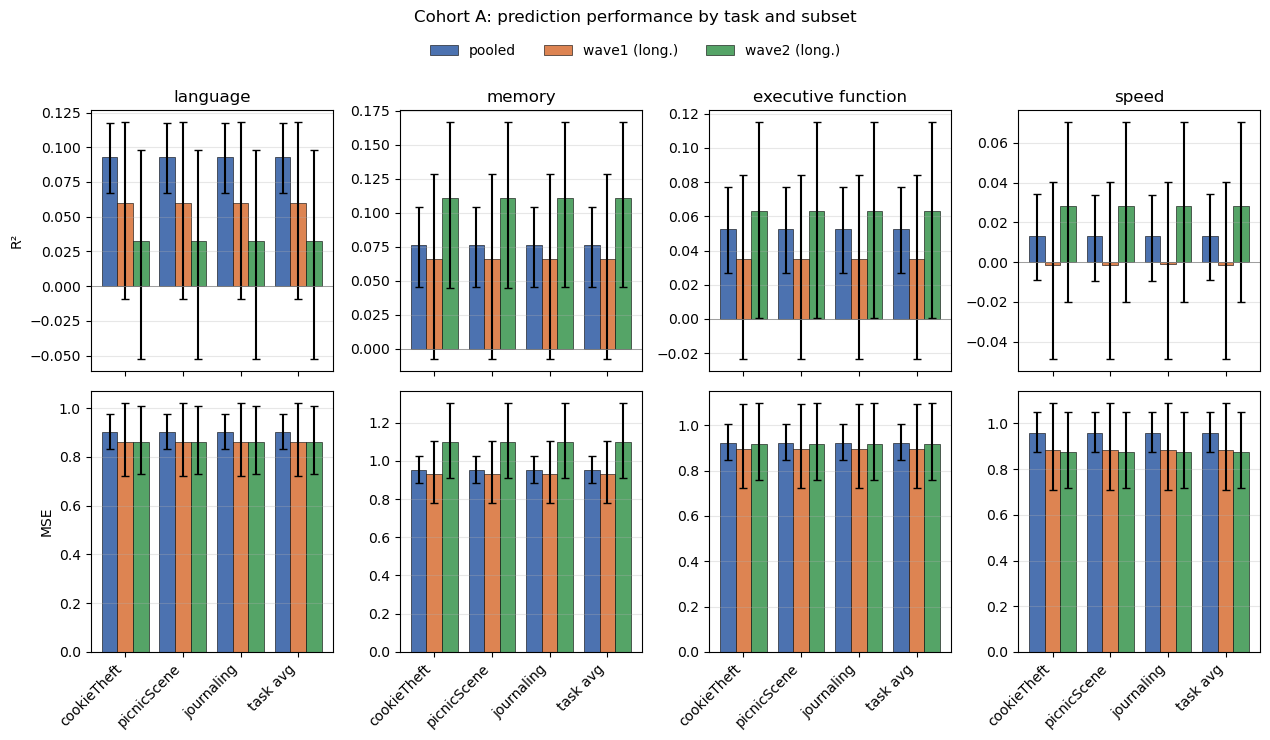

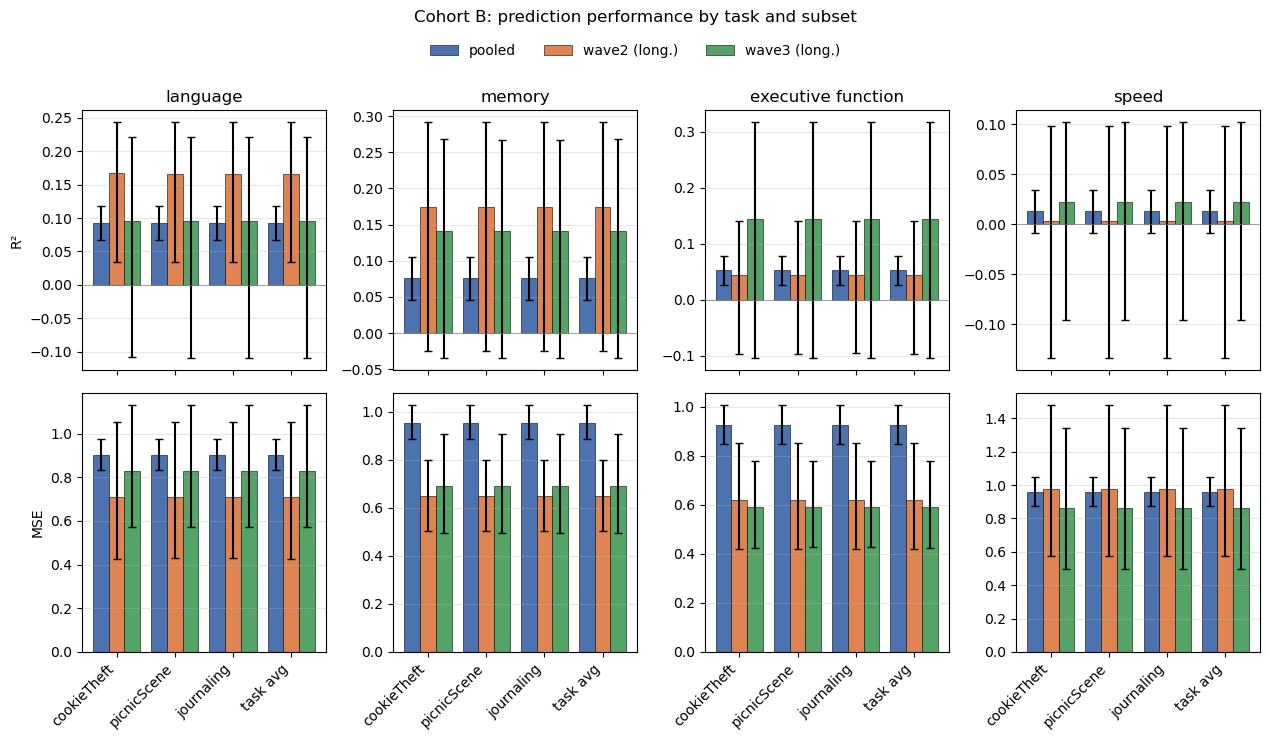

In [40]:
def plot_eval_bars(eval_df, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        2, len(targets),
        figsize=(3.2 * len(targets), 7),
        sharex=True,
    )
    if len(targets) == 1:
        axes = axes.reshape(2, 1)

    task_order = tasks + ['average']
    task_labels = tasks + ['task avg']
    subsets = ['pooled', f'{wave_a}_longitudinal', f'{wave_b}_longitudinal']
    subset_labels = {
        'pooled': 'pooled',
        f'{wave_a}_longitudinal': f'{wave_a} (long.)',
        f'{wave_b}_longitudinal': f'{wave_b} (long.)',
    }
    subset_colors = {
        'pooled': '#4c72b0',
        f'{wave_a}_longitudinal': '#dd8452',
        f'{wave_b}_longitudinal': '#55a467',
    }

    # Filter eval_df to the rows for this cohort + pooled
    cohort_rows = eval_df[(eval_df['cohort'] == label) | (eval_df['cohort'] == '-')]

    x = np.arange(len(task_order))
    width = 0.27

    for metric_idx, metric in enumerate(['r2', 'mse']):
        for col_idx, target in enumerate(targets):
            ax = axes[metric_idx, col_idx]
            for i, subset in enumerate(subsets):
                sub = (cohort_rows[
                    (cohort_rows['target'] == target)
                    & (cohort_rows['subset'] == subset)
                ].set_index('task').loc[task_order])
                y = sub[metric].values
                err_lo = y - sub[f'{metric}_ci_low'].values
                err_hi = sub[f'{metric}_ci_high'].values - y
                offset = (i - 1) * width
                ax.bar(
                    x + offset, y, width, yerr=[err_lo, err_hi],
                    color=subset_colors[subset],
                    label=subset_labels[subset]
                        if (metric_idx == 0 and col_idx == 0) else None,
                    capsize=3, edgecolor='black', linewidth=0.4,
                )
            ax.axhline(0, color='grey', linewidth=0.5)
            ax.set_xticks(x)
            ax.set_xticklabels(task_labels, rotation=45, ha='right')
            ax.grid(axis='y', alpha=0.3)
            if metric_idx == 0:
                ax.set_title(target.replace('_', ' '))
            if col_idx == 0:
                ax.set_ylabel('R²' if metric == 'r2' else 'MSE')

    fig.legend(loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, frameon=False)
    fig.suptitle(
        f'Cohort {label}: prediction performance by task and subset',
        y=1.05,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_eval_bars(eval_df, label, wave_a, wave_b, targets, tasks)

## Test-retest reliability (ICC(3,1))

For each cohort, compute ICC(3,1) between its two waves on:
- the cognitive composite score (target)
- each task's speech-based prediction
- the per-participant cross-task average prediction
- the picture-description average (cookieTheft + picnicScene)

In [41]:
def compute_icc3(df, col_a, col_b, wave_a, wave_b):
    """ICC(3,1) measures taken from a wide-format df. Returns (icc, ci_low, ci_high, n).
    """
    sub = df.loc[:, [col_a, col_b]].dropna()
    ids = sub.index.astype(str).tolist()
    melted = pd.DataFrame({
        'id': ids * 2,
        'wave': [wave_a] * len(sub) + [wave_b] * len(sub),
        'score': np.concatenate([sub[col_a].values, sub[col_b].values]),
    })
    icc = pg.intraclass_corr(
        data=melted, targets='id', raters='wave',
        ratings='score', nan_policy='omit',
    )
    mask = icc['Type'].isin(['ICC3'])
    row = icc[mask].iloc[0]
    ci_col = 'CI95'
    ci_low, ci_high = row[ci_col]
    return row['ICC'], ci_low, ci_high, len(sub)


def build_reliability_df(longitudinal_by_cohort, cohorts, targets, tasks):
    """Long-format df of ICC(3,1) for composite scores and predictions, stacked
    across cohorts with a `cohort` column."""
    rows = []
    for label, wave_a, wave_b in cohorts:
        long_df = longitudinal_by_cohort[label]
        for target in targets:
            # Composite score reliability
            icc, lo, hi, n = compute_icc3(
                long_df,
                (wave_a, target, 'target'),
                (wave_b, target, 'target'),
                wave_a, wave_b,
            )
            rows.append({
                'cohort': label, 'measure': 'composite_score',
                'target': target, 'task': None,
                'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
            })

            # Per-task prediction reliability
            for task in tasks:
                icc, lo, hi, n = compute_icc3(
                    long_df,
                    (wave_a, target, task),
                    (wave_b, target, task),
                    wave_a, wave_b,
                )
                rows.append({
                    'cohort': label, 'measure': 'prediction',
                    'target': target, 'task': task,
                    'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
                })

            # Cross-task average prediction reliability
            avg_a = long_df.loc[:, [(wave_a, target, t) for t in tasks]].mean(axis=1)
            avg_b = long_df.loc[:, [(wave_b, target, t) for t in tasks]].mean(axis=1)
            tmp = pd.DataFrame({'avg_a': avg_a, 'avg_b': avg_b})
            icc, lo, hi, n = compute_icc3(tmp, 'avg_a', 'avg_b', wave_a, wave_b)
            rows.append({
                'cohort': label, 'measure': 'prediction',
                'target': target, 'task': 'average',
                'n': n, 'icc': icc, 'icc_ci_low': lo, 'icc_ci_high': hi,
            })

    return pd.DataFrame(rows)

In [42]:
reliability_df = build_reliability_df(longitudinal_by_cohort, COHORTS, targets, tasks)
reliability_df

,cohort,measure,target,task,n,icc,icc_ci_low,icc_ci_high
0,A,composite_score,language,NaN,294,0.685989,0.62,0.74
1,A,prediction,language,cookieTheft,294,0.974114,0.97,0.98
2,A,prediction,language,picnicScene,294,0.974111,0.97,0.98
3,A,prediction,language,journaling,294,0.974113,0.97,0.98
4,A,prediction,language,average,294,0.974113,0.97,0.98
5,A,composite_score,memory,NaN,294,0.681167,0.61,0.74
6,A,prediction,memory,cookieTheft,294,0.975112,0.97,0.98
7,A,prediction,memory,picnicScene,294,0.975113,0.97,0.98
8,A,prediction,memory,journaling,294,0.975114,0.97,0.98
9,A,prediction,memory,average,294,0.975113,0.97,0.98


In [43]:
# Wide views: one row per (cohort, target), columns show composite + each task + averages.
_rel = reliability_df.copy()
_rel['icc_str'] = _rel.apply(
    lambda r: f"{r['icc']:.2f} [{r['icc_ci_low']:.2f}, {r['icc_ci_high']:.2f}]", axis=1
)
_rel['col'] = _rel['measure'].where(_rel['measure'] == 'composite_score', _rel['task'])
reliability_wide = _rel.pivot_table(
    index=['cohort', 'target'], columns='col', values='icc_str', aggfunc='first',
)
ordered_cols = ['composite_score'] + tasks + ['average']#, 'pictureDescription']
reliability_wide = reliability_wide.loc[
    :, [c for c in ordered_cols if c in reliability_wide.columns]
]
reliability_wide

col                          composite_score        cookieTheft  \
cohort target                                                     
A      executive_function  0.71 [0.65, 0.76]  0.98 [0.97, 0.98]   
       language            0.69 [0.62, 0.74]  0.97 [0.97, 0.98]   
       memory              0.68 [0.61, 0.74]  0.98 [0.97, 0.98]   
       speed               0.76 [0.71, 0.81]  0.95 [0.94, 0.96]   
B      executive_function  0.81 [0.71, 0.88]  1.00 [0.99, 1.00]   
       language            0.72 [0.58, 0.82]  0.99 [0.98, 0.99]   
       memory              0.76 [0.64, 0.84]  0.99 [0.98, 0.99]   
       speed               0.87 [0.79, 0.92]  0.99 [0.98, 0.99]   

col                              picnicScene         journaling  \
cohort target                                                     
A      executive_function  0.98 [0.97, 0.98]  0.98 [0.97, 0.98]   
       language            0.97 [0.97, 0.98]  0.97 [0.97, 0.98]   
       memory              0.98 [0.97, 0.98]  0.98 [0.97, 0.98]   
       speed               0.95 [0.94, 0.96]  0.95 [0.94, 0.96]   
B      executive_function  1.00 [0.99, 1.00]  1.00 [0.99, 1.00]   
       language            0.99 [0.98, 0.99]  0.99 [0.98, 0.99]   
       memory              0.99 [0.98, 0.99]  0.99 [0.98, 0.99]   
       speed               0.99 [0.98, 0.99]  0.99 [0.98, 0.99]   

col                                  average  
cohort target                                 
A      executive_function  0.98 [0.97, 0.98]  
       language            0.97 [0.97, 0.98]  
       memory              0.98 [0.97, 0.98]  
       speed               0.95 [0.94, 0.96]  
B      executive_function  1.00 [0.99, 1.00]  
       language            0.99 [0.98, 0.99]  
       memory              0.99 [0.98, 0.99]  
       speed               0.99 [0.98, 0.99]

In [44]:
def emit_reliability_table(reliability_wide, targets, label, wave_a, wave_b):
    pieces = []
    for target in targets:
        col = reliability_wide.loc[(label, target), :]
        pieces.append(col.rename(f'\\textit{{{rename_target(target)}}}'))
    table = pd.concat(pieces, axis=1)

    row_rename = {
        'composite_score': 'Cognitive composite score',
        'cookieTheft': 'Predictions: Cookie Theft',
        'picnicScene': 'Predictions: Picnic Scene',
        'journaling': 'Predictions: Journaling',
        'average': 'Predictions: Avg. Prediction',
    }
    table = table.rename(index=row_rename).reset_index().rename(columns={'col': ''})

    targets_str = ', '.join(f'\\textit{{{rename_target(t)}}}' for t in targets)
    print(table.to_latex(
        float_format='%.2f',
        column_format='l' + 'c' * (len(table.columns) - 1),
        index=False,
        caption=(
            f"Test-retest reliability (ICC) of the cognitive composite scores and the speech-based predictions between baseline and follow-up (Cohort {label}). We report point estimates with 95\\% bootstrap CI."
        ),
        label=f's_tab:reliability_cohort{label}',
    ))


for label, wave_a, wave_b in COHORTS:
    print(f'\n% === Reliability — Cohort {label} ({now()}) ===')
    emit_reliability_table(reliability_wide, targets, label, wave_a, wave_b)


% === Reliability — Cohort A (2026-09-22 11:51) ===
\begin{table}
\caption{Test-retest reliability (ICC) of the cognitive composite scores and the speech-based predictions between baseline and follow-up (Cohort A). We report point estimates with 95\% bootstrap CI.}
\label{s_tab:reliability_cohortA}
\begin{tabular}{lcccc}
\toprule
 & \textit{Language} & \textit{Memory} & \textit{Executive Function} & \textit{Speed} \\
\midrule
Cognitive composite score & 0.69 [0.62, 0.74] & 0.68 [0.61, 0.74] & 0.71 [0.65, 0.76] & 0.76 [0.71, 0.81] \\
Predictions: Cookie Theft & 0.97 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.95 [0.94, 0.96] \\
Predictions: Picnic Scene & 0.97 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.95 [0.94, 0.96] \\
Predictions: Journaling & 0.97 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.95 [0.94, 0.96] \\
Predictions: Avg. Prediction & 0.97 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.98 [0.97, 0.98] & 0.95 [0.94, 0.96] \\
\bottomrule
\end{tabula

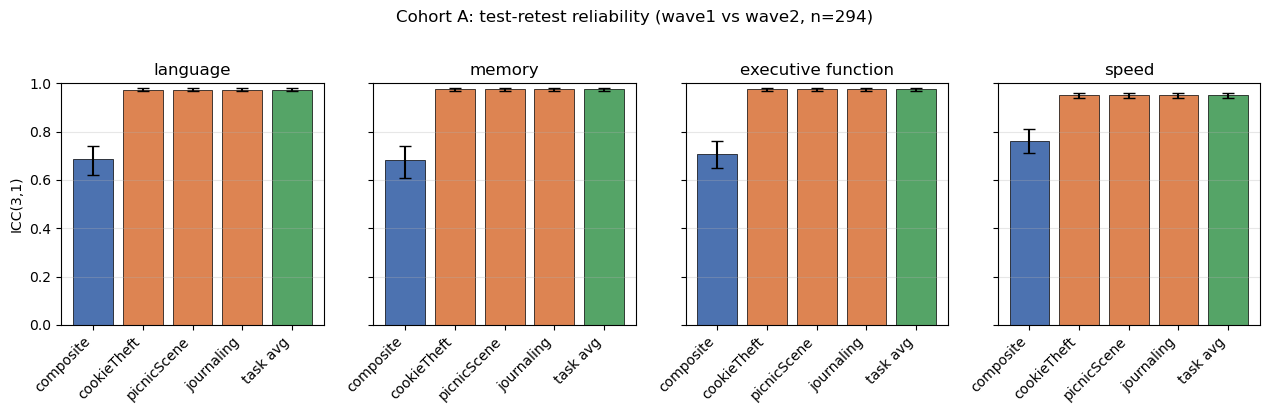

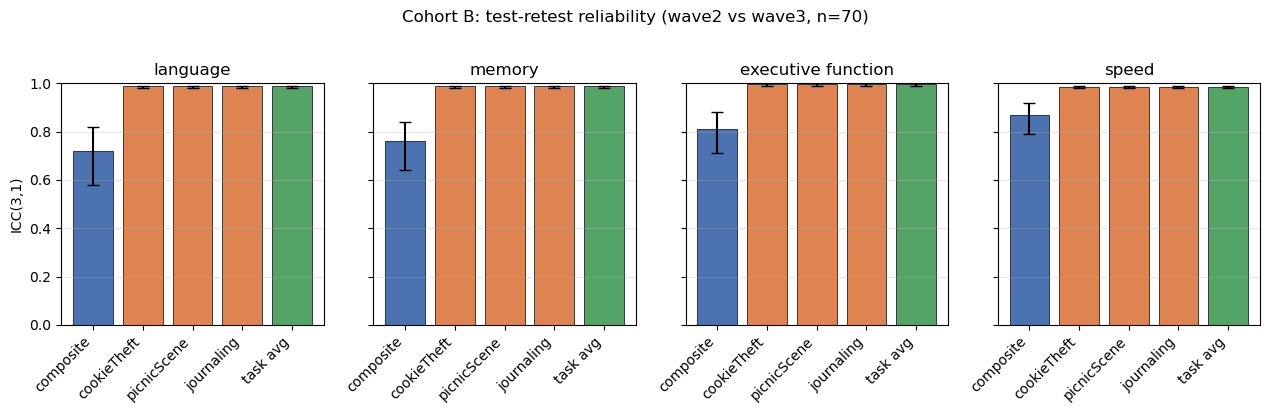

In [45]:
def plot_reliability_bars(reliability_df, label, wave_a, wave_b, targets, tasks):
    fig, axes = plt.subplots(
        1, len(targets),
        figsize=(3.2 * len(targets), 4),
        sharey=True,
    )
    if not isinstance(axes, Iterable):
        axes = [axes]

    col_order = ['composite_score'] + tasks + ['average']
    col_labels = ['composite'] + tasks + ['task avg']

    sample_sizes = []
    cohort_rows = reliability_df[reliability_df['cohort'] == label]
    for ax, target in zip(axes, targets):
        sub = cohort_rows[cohort_rows['target'] == target].copy()
        n = sub['n'].to_list()
        sample_sizes.extend(n)
        sub['col'] = sub['measure'].where(sub['measure'] == 'composite_score', sub['task'])
        sub = sub.set_index('col').loc[col_order]

        x = np.arange(len(col_order))
        y = sub['icc'].values
        err_lo = y - sub['icc_ci_low'].values
        err_hi = sub['icc_ci_high'].values - y

        colors = ['#4c72b0'] + ['#dd8452'] * len(tasks) + ['#55a467', '#55a467']
        ax.bar(
            x, y, yerr=[err_lo, err_hi], color=colors, capsize=4,
            edgecolor='black', linewidth=0.5,
        )
        ax.axhline(0, color='grey', linewidth=0.5)
        ax.set_xticks(x)
        ax.set_xticklabels(col_labels, rotation=45, ha='right')
        ax.set_title(target.replace('_', ' '))
        ax.set_ylim(min(0, sub['icc_ci_low'].min() - 0.05), 1.0)
        ax.grid(axis='y', alpha=0.3)

    axes[0].set_ylabel('ICC(3,1)')
    sample_sizes_text = (
        list(set(sample_sizes))[0] if len(set(sample_sizes)) == 1
        else f"{sample_sizes}"
    )
    fig.suptitle(
        f'Cohort {label}: test-retest reliability '
        f'({wave_a} vs {wave_b}, n={sample_sizes_text})',
        y=1.02,
    )
    plt.tight_layout()
    plt.show()


for label, wave_a, wave_b in COHORTS:
    plot_reliability_bars(reliability_df, label, wave_a, wave_b, targets, tasks)

In [46]:
# test-retest reliability of picnicScene vs cookieTheft predictions
# using ICC(3,1)
# (crosssectional data + combined waves within each cohort)

import pingouin as pg

rows = []

def compute_icc_across_tasks(x, y):
    df_icc = pd.DataFrame({
        'subject': range(len(x)),
        'cookieTheft': x.values,
        'picnicScene': y.values,
    })

    long_icc = df_icc.melt(
        id_vars='subject',
        var_name='rater',
        value_name='score'
    )

    icc_table = pg.intraclass_corr(
        data=long_icc,
        targets='subject',
        raters='rater',
        ratings='score'
    )

    icc31 = icc_table[icc_table['Type'] == 'ICC3'].iloc[0]

    return icc31['ICC'], icc31['CI95']


# all data
for target in targets:
    x = crosssectional[(target, 'cookieTheft')]
    y = crosssectional[(target, 'picnicScene')]

    mask = x.notna() & y.notna()

    icc, ci95 = compute_icc_across_tasks(
        x[mask].reset_index(drop=True),
        y[mask].reset_index(drop=True)
    )

    rows.append({
        'target': target,
        'Cohort': f'Entire data',
        '\\# Observations': int(mask.sum()),
        'ICC [95\\% CI]': f'{icc:.2f} [{ci95[0]:.2f}, {ci95[1]:.2f}]',
    })

# each cohort
for label, wave_a, wave_b in COHORTS:
    long_df = longitudinal_by_cohort[label]

    for target in targets:

        x = pd.concat([
            long_df[(wave_a, target, 'cookieTheft')],
            long_df[(wave_b, target, 'cookieTheft')],
        ], ignore_index=True)

        y = pd.concat([
            long_df[(wave_a, target, 'picnicScene')],
            long_df[(wave_b, target, 'picnicScene')],
        ], ignore_index=True)

        mask = x.notna() & y.notna()

        icc, ci95 = compute_icc_across_tasks(
            x[mask].reset_index(drop=True),
            y[mask].reset_index(drop=True)
        )

        rows.append({
            'target': target,
            'Cohort': f"Cohort {label}",
            '\\# Observations': int(mask.sum()),
            'ICC [95\\% CI]': f'{icc:.2f} [{ci95[0]:.2f}, {ci95[1]:.2f}]',
        })


picnic_vs_cookie_reliability_df = pd.DataFrame(rows).query("target == 'language'").drop(columns=['target'])

picnic_vs_cookie_reliability_df

,Cohort,\# Observations,ICC [95\% CI]
0,Entire data,1454,"1.00 [1.00, 1.00]"
4,Cohort A,599,"1.00 [1.00, 1.00]"
8,Cohort B,140,"1.00 [1.00, 1.00]"


In [47]:
picnic_vs_cookie_reliability_latex = picnic_vs_cookie_reliability_df.to_latex(
    index=False,
    column_format='l' * (len(picnic_vs_cookie_reliability_df.columns)),
    caption=(
        "Test-retest reliability (ICC) comparing the Cookie Theft and Picnic Scene speech predictions of the same participant at the same data wave. Results are given for the \\textit{language} composite cognitive score, and computed across the entire data set and within each cohort. We report point estimates with 95\\% bootstrap CI."
    ),
    label='tab:picnic_cookie_reliability',)
print(f"% === Test retest cookieTheft vs. picnicScene ({now()}) ===")
print(picnic_vs_cookie_reliability_latex)

% === Test retest cookieTheft vs. picnicScene (2026-09-22 11:51) ===
\begin{table}
\caption{Test-retest reliability (ICC) comparing the Cookie Theft and Picnic Scene speech predictions of the same participant at the same data wave. Results are given for the \textit{language} composite cognitive score, and computed across the entire data set and within each cohort. We report point estimates with 95\% bootstrap CI.}
\label{tab:picnic_cookie_reliability}
\begin{tabular}{lll}
\toprule
Cohort & \# Observations & ICC [95\% CI] \\
\midrule
Entire data & 1454 & 1.00 [1.00, 1.00] \\
Cohort A & 599 & 1.00 [1.00, 1.00] \\
Cohort B & 140 & 1.00 [1.00, 1.00] \\
\bottomrule
\end{tabular}
\end{table}



In [48]:
# Longitudinal change in prediction scores across waves within each cohort
# Per task + averaged prediction across tasks
# Single combined summary table


from scipy.stats import ttest_rel

rows = []
TASKS = ['cookieTheft', 'picnicScene', 'journaling']
for label, wave_a, wave_b in COHORTS:
    long_df = longitudinal_by_cohort[label]
    for target in targets:
        score_sets = {
            task: (
                long_df[(wave_a, target, task)],
                long_df[(wave_b, target, task)],
            )
            for task in TASKS
        }
        score_sets['average_prediction'] = (
            pd.concat([v[0] for v in score_sets.values()], axis=1).mean(axis=1),
            pd.concat([v[1] for v in score_sets.values()], axis=1).mean(axis=1),
        )
        for task, (x, y) in score_sets.items():
            mask = x.notna() & y.notna()
            x, y = x[mask], y[mask]
            diff = y - x
            _, pval = ttest_rel(y, x)
            rows.append({
                'Cognitive domain': rename_target(target),
                'Cohort': f"Cohort {label}",
                'Task': rename_tasks.get(task,task),
                "Baseline": f'{x.mean():.2f} $\\pm$ {x.std():.2f}',
                "Follow-up": f'{y.mean():.2f} $\\pm$ {y.std():.2f}',
                '% Improv. / % Decline':
                    f'{(diff > 0).mean()*100:.1f}% / {(diff < 0).mean()*100:.1f}%',
                'Difference':
                    f'{diff.mean():.2f} $\\pm$ {diff.std():.2f}',
                'p-val': f'{pval:.2g}',
            })

#longitudinal_prediction_summary_df = pd.DataFrame(rows)#.query("target == 'language'").drop(columns=['target'])
longitudinal_prediction_summary_df = pd.DataFrame(rows).query("Cohort == 'Cohort B'").drop(columns=['Cohort'])
#longitudinal_prediction_summary_df = longitudinal_prediction_summary_df.set_index("Cognitive domain")
longitudinal_prediction_summary_df


,Cognitive domain,Task,Baseline,Follow-up,% Improv. / % Decline,Difference,p-val
16,Language,Cookie Theft,0.31 $\pm$ 0.23,0.31 $\pm$ 0.22,22.9% / 25.7%,-0.00 $\pm$ 0.04,0.9
17,Language,Picnic Scene,0.31 $\pm$ 0.23,0.30 $\pm$ 0.22,22.9% / 25.7%,-0.00 $\pm$ 0.04,0.9
18,Language,Journaling,0.30 $\pm$ 0.23,0.30 $\pm$ 0.22,22.9% / 25.7%,-0.00 $\pm$ 0.04,0.9
19,Language,Avg. Prediction,0.31 $\pm$ 0.23,0.30 $\pm$ 0.22,22.9% / 25.7%,-0.00 $\pm$ 0.04,0.9
20,Memory,Cookie Theft,0.21 $\pm$ 0.30,0.21 $\pm$ 0.29,22.9% / 25.7%,0.00 $\pm$ 0.04,0.74
21,Memory,Picnic Scene,0.21 $\pm$ 0.29,0.21 $\pm$ 0.29,22.9% / 25.7%,0.00 $\pm$ 0.04,0.74
22,Memory,Journaling,0.21 $\pm$ 0.29,0.21 $\pm$ 0.29,22.9% / 25.7%,0.00 $\pm$ 0.04,0.74
23,Memory,Avg. Prediction,0.21 $\pm$ 0.29,0.21 $\pm$ 0.29,22.9% / 25.7%,0.00 $\pm$ 0.04,0.74
24,Executive Function,Cookie Theft,0.28 $\pm$ 0.25,0.28 $\pm$ 0.25,18.6% / 30.0%,-0.00 $\pm$ 0.02,0.053
25,Executive Function,Picnic Scene,0.28 $\pm$ 0.25,0.28 $\pm$ 0.25,18.6% / 30.0%,-0.00 $\pm$ 0.02,0.053


In [49]:

longitudinal_prediction_summary_latex = longitudinal_prediction_summary_df.to_latex(
    index=False,
    column_format='l' * (len(longitudinal_prediction_summary_df.columns)),
    caption=(
        "Longitudinal change in speech-based predictions across assessments within each cohort. We compare the baseline and follow-up assessment of the same participants in the two cohorts, testing for significant differences with paired $t$-tests. Results are given for Cohort B, and computed separately for each task's predictions and the average prediction across tasks."
    ),
    label='tab:longitudinal_prediction_change_cohortB',).replace("%", "\\%")
print(f"% === Longitudinal change in prediction scores ({now()}) ===")
print(longitudinal_prediction_summary_latex)

% === Longitudinal change in prediction scores (2026-09-22 11:51) ===
\begin{table}
\caption{Longitudinal change in speech-based predictions across assessments within each cohort. We compare the baseline and follow-up assessment of the same participants in the two cohorts, testing for significant differences with paired $t$-tests. Results are given for Cohort B, and computed separately for each task's predictions and the average prediction across tasks.}
\label{tab:longitudinal_prediction_change_cohortB}
\begin{tabular}{lllllll}
\toprule
Cognitive domain & Task & Baseline & Follow-up & \% Improv. / \% Decline & Difference & p-val \\
\midrule
Language & Cookie Theft & 0.31 $\pm$ 0.23 & 0.31 $\pm$ 0.22 & 22.9\% / 25.7\% & -0.00 $\pm$ 0.04 & 0.9 \\
Language & Picnic Scene & 0.31 $\pm$ 0.23 & 0.30 $\pm$ 0.22 & 22.9\% / 25.7\% & -0.00 $\pm$ 0.04 & 0.9 \\
Language & Journaling & 0.30 $\pm$ 0.23 & 0.30 $\pm$ 0.22 & 22.9\% / 25.7\% & -0.00 $\pm$ 0.04 & 0.9 \\
Language & Avg. Prediction & 0.31 